<a href="https://colab.research.google.com/github/sebi-varkey/AL-ML-intership/blob/main/day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Summary Statistics:
              crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis       

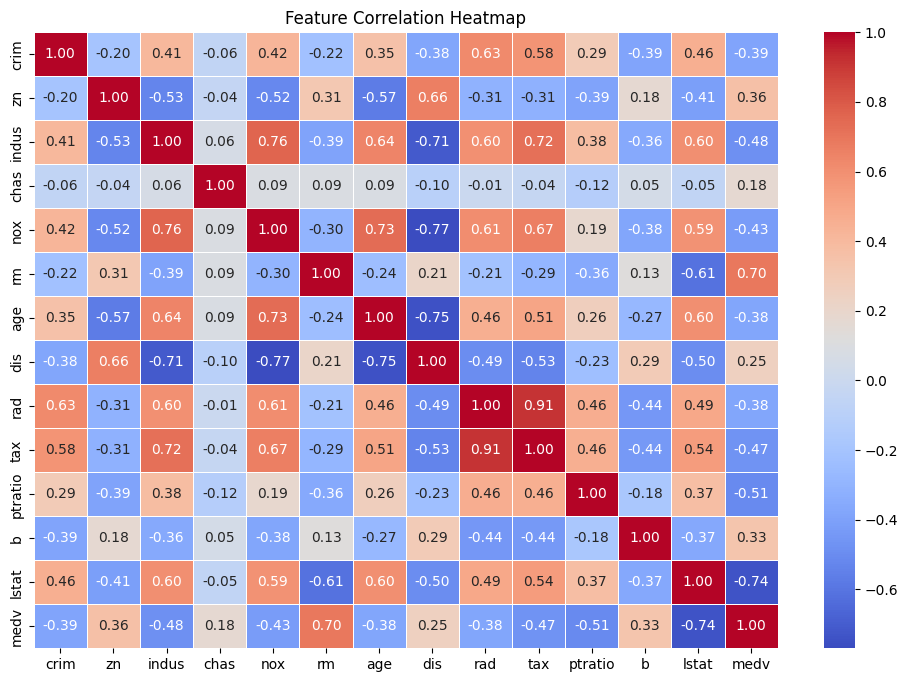

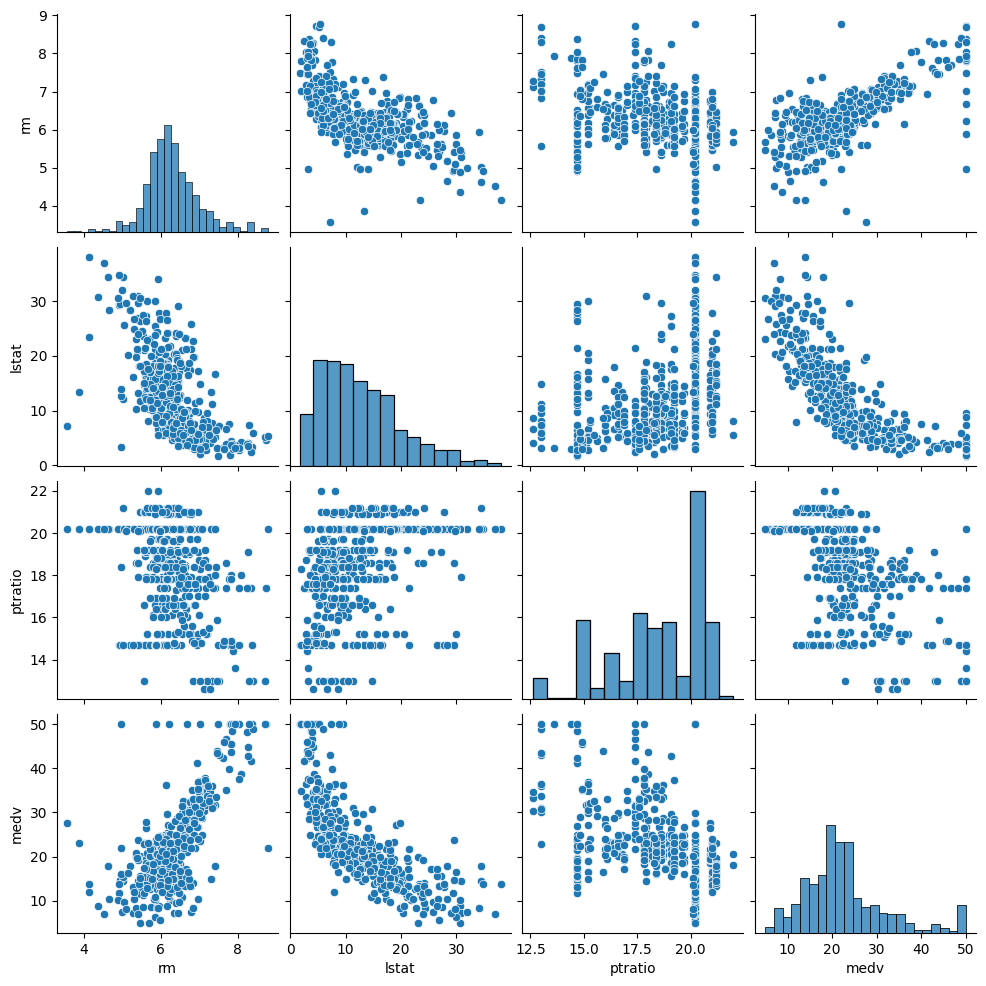

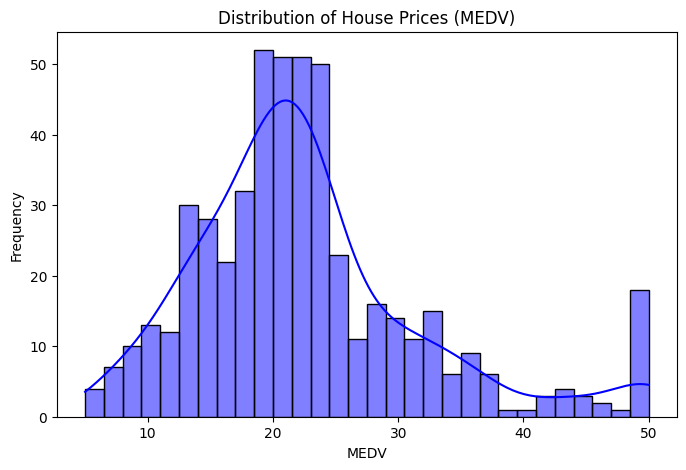

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Load the dataset
df = pd.read_csv("/content/boston.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['rm', 'lstat', 'ptratio', 'medv']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['medv'], bins=30, kde=True, color='blue')
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.6688
RMSE: 4.9286


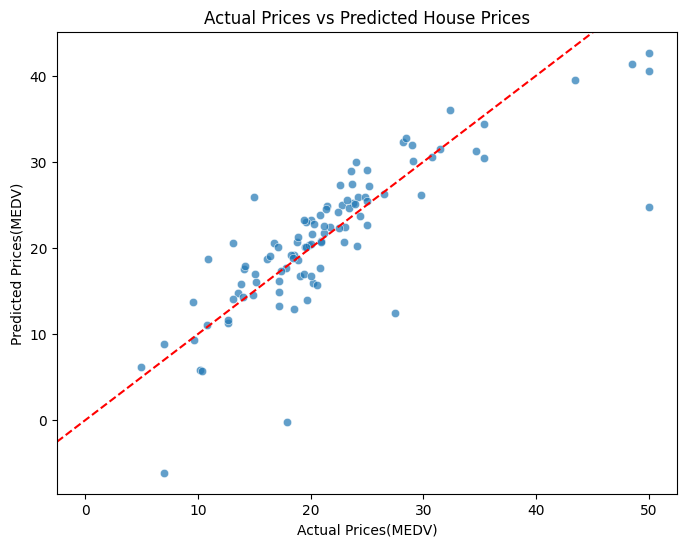

<Figure size 1000x4200 with 0 Axes>

<Figure size 1000x4200 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices(MEDV)")
plt.ylabel("Predicted Prices(MEDV)")
plt.title("Actual Prices vs Predicted House Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()
skewness =df.skew()

num_cols = len(df.columns)
plt.figure(figsize=(10, num_cols * 3))



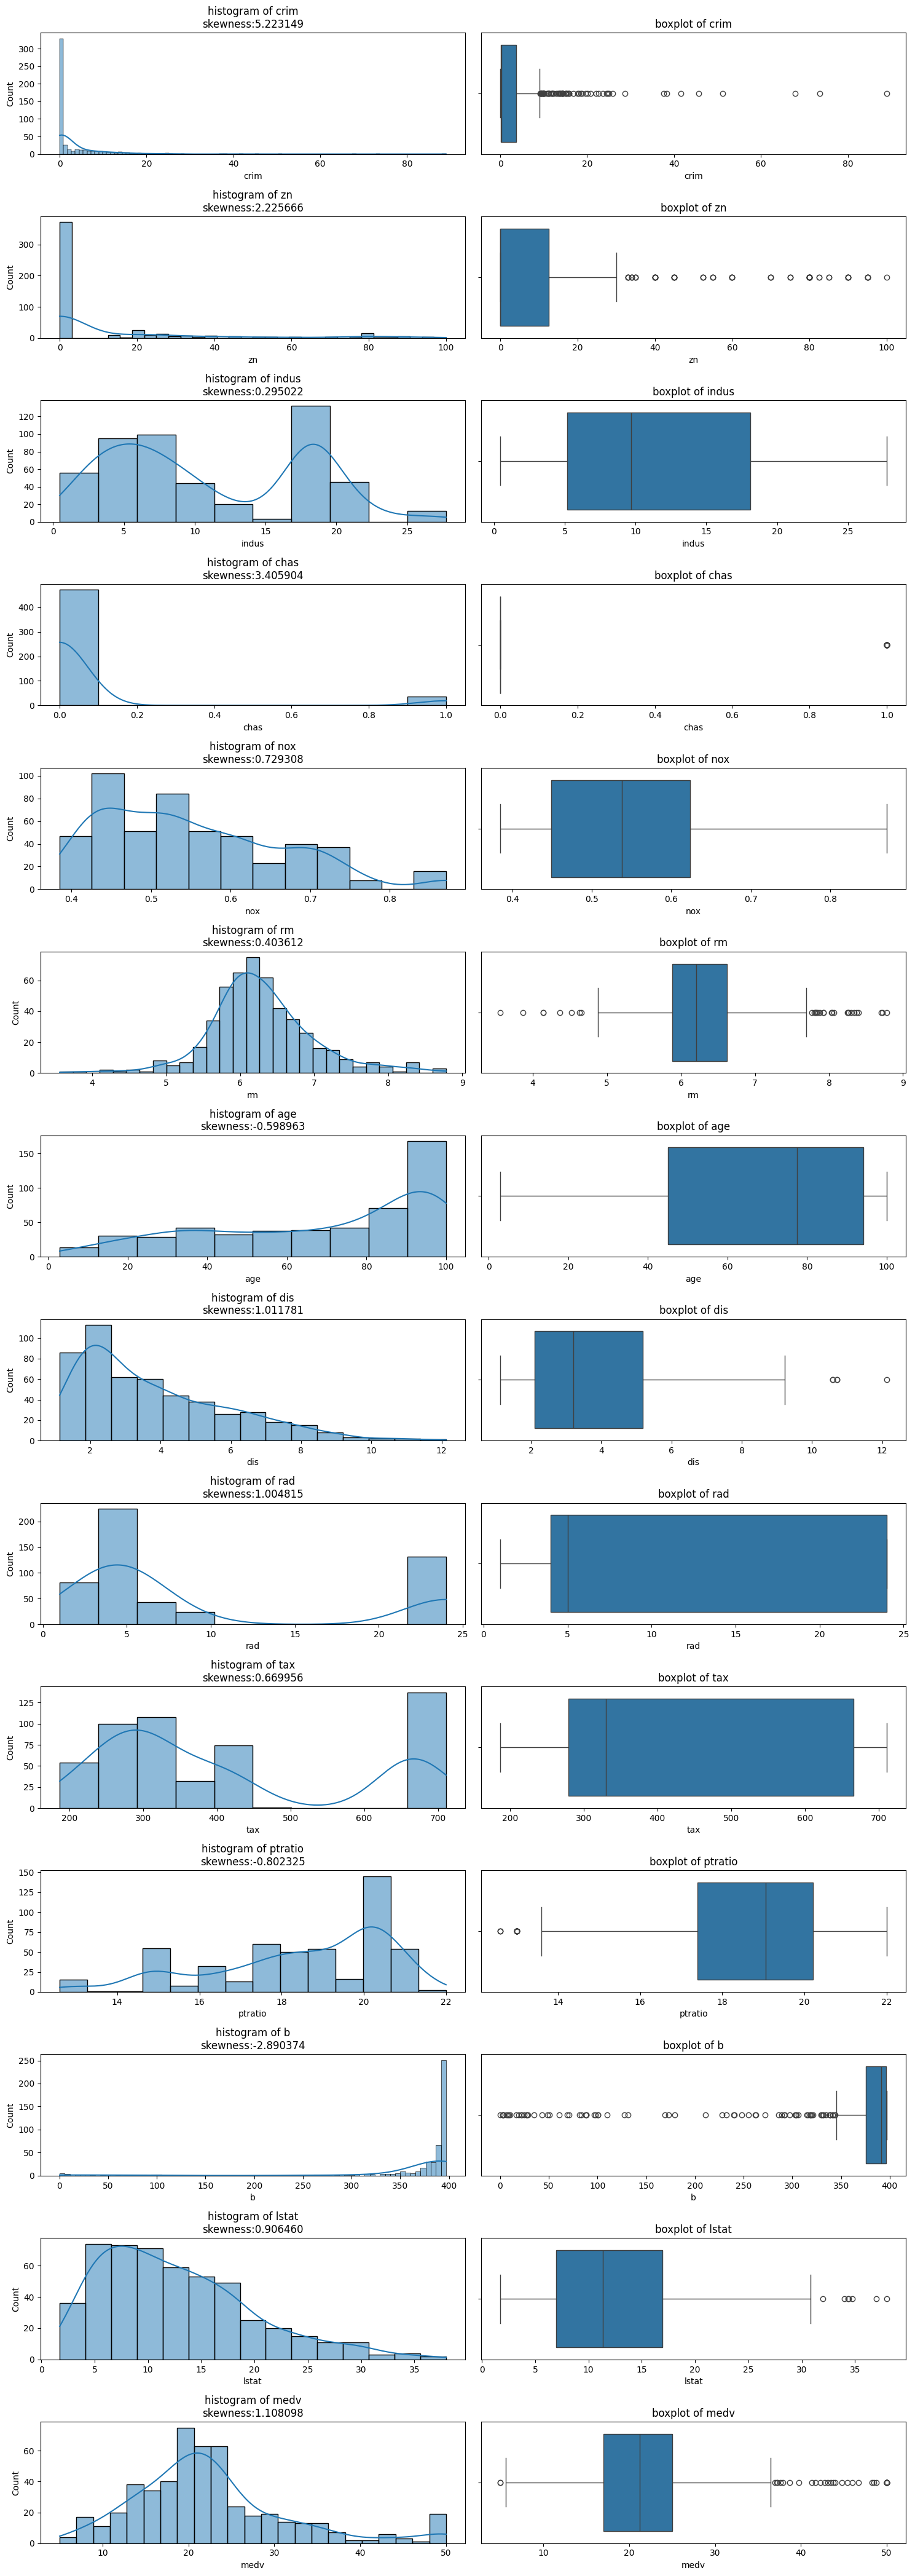

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
skewness=df.skew()
num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))
for i,col in enumerate(df.columns):
  plt.subplot(num_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f'histogram of {col}\nskewness:{skewness[col]:2f}')
  plt.subplot(num_cols,2,2*i+2)
  sns.boxplot(x=df[col])
  plt.title(f'boxplot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
skewed_cols = df.skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("highly skewed columns:\n",highly_skewed)
print("negatively skewed columns:\n",negatively_skewed)

highly skewed columns:
 Index(['crim', 'zn', 'chas', 'dis', 'rad', 'b', 'medv'], dtype='object')
negatively skewed columns:
 Index(['indus', 'nox', 'rm', 'age', 'tax', 'ptratio', 'lstat'], dtype='object')


In [ ]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))
print(df[highly_skewed])

         crim        zn  chas       dis       rad         b      medv
0    0.006300  2.944439   0.0  1.627278  0.693147  5.986201  3.218876
1    0.026944  0.000000   0.0  1.786261  1.098612  5.986201  3.117950
2    0.026924  0.000000   0.0  1.786261  1.098612  5.975919  3.575151
3    0.031857  0.000000   0.0  1.954757  1.386294  5.980479  3.538057
4    0.066770  0.000000   0.0  1.954757  1.386294  5.986201  3.616309
..        ...       ...   ...       ...       ...       ...       ...
501  0.060747  0.000000   0.0  1.246630  0.693147  5.973784  3.152736
502  0.044275  0.000000   0.0  1.190127  0.693147  5.986201  3.072693
503  0.058986  0.000000   0.0  1.152943  0.693147  5.986201  3.214868
504  0.103991  0.000000   0.0  1.220505  0.693147  5.977492  3.135494
505  0.046320  0.000000   0.0  1.254191  0.693147  5.986201  2.557227

[506 rows x 7 columns]


In [ ]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])
df[negatively_skewed]


,indus,nox,rm,age,tax,ptratio,lstat
0,-1.523776,0.027165,0.441377,-0.212875,-0.556334,-1.408874,-1.257099
1,-0.443938,-0.716093,0.225621,0.314385,-1.175887,-0.518692,-0.334422
2,-0.443938,-0.716093,1.268348,-0.363383,-1.175887,-0.518692,-1.543453
3,-1.564275,-0.851247,1.019336,-0.891929,-1.461842,-0.076443,-1.934975
4,-1.564275,-0.851247,1.218056,-0.608476,-1.461842,-0.076443,-1.161275
...,...,...,...,...,...,...,...
501,0.293061,0.344891,0.466404,-0.066501,-0.797315,1.430705,-0.241376
502,0.293061,0.344891,-0.204867,0.227305,-0.797315,1.430705,-0.345213
503,0.293061,0.344891,0.989786,0.808711,-0.797315,1.430705,-1.080078
504,0.293061,0.344891,0.743218,0.737737,-0.797315,1.430705,-0.875162


In [ ]:
df.skew()

,0
crim,1.269201
zn,1.193451
indus,-0.104641
chas,3.405904
nox,0.098431
rm,0.023275
age,-0.417736
dis,0.331561
rad,0.532760
tax,0.079613


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.7555
RMSE: 0.1842


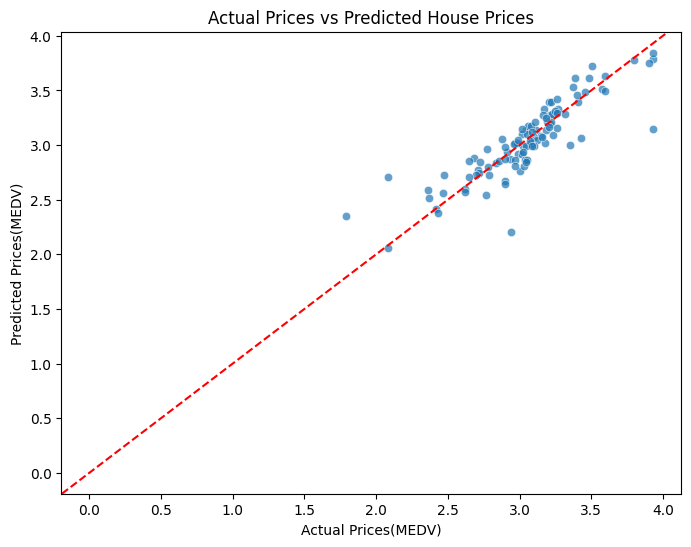

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices(MEDV)")
plt.ylabel("Predicted Prices(MEDV)")
plt.title("Actual Prices vs Predicted House Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)**0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.8692
RMSE: 0.1842
